In [1]:
import os, sys
# Force the C++ backend to shut up BEFORE it boots
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import warnings
import time

import pandas as pd
import numpy as np
import math

import pickle

from matplotlib import pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.lines import Line2D
import seaborn as sns
import plotly.graph_objects as go
from IPython.display import Image, display
from PIL import Image

import lifelines
from lifelines.utils import concordance_index
from lifelines.statistics import logrank_test
from sksurv.util import Surv
from sksurv.metrics import concordance_index_ipcw

import tensorflow as tf
tf.get_logger().setLevel('ERROR')
import tensorflow_probability as tfp

config = tf.compat.v1.ConfigProto()
config.gpu_options.allow_growth = True
sess = tf.compat.v1.Session(config = config)

from tensorflow import keras
from tensorflow.keras import optimizers, initializers, regularizers, layers

import scipy.stats as stats
from scipy.stats import norm, t, probplot, pearsonr, spearmanr, rankdata
from scipy.stats import truncnorm as truncnorm_scipy
from scipy.stats import gamma as gamma_dist
from scipy.special import gamma

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, KFold

import thetaflow as thf
import truncnorm

# Add utils file to path so we can import it
import gndr_utils as utils

2026-10-05 16:56:02.793104: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1791230162.810066   52553 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1791230162.815011   52553 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1791230162.827922   52553 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791230162.827945   52553 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1791230162.827947   52553 computation_placer.cc:177] computation placer alr

In [2]:
norm.cdf(1) - norm.cdf(-1)

np.float64(0.6826894921370859)

In [3]:
norm.cdf(-1)

np.float64(0.15865525393145707)

In [4]:
thf.__version__

'0.0.38'

In [5]:
from tensorflow.python.client import device_lib

devices = device_lib.list_local_devices()
for d in devices:
    print(f"Name: {d.name}")
    print(f"Type: {d.device_type}")
    print(f"Memory limit: {d.memory_limit}")
    print(f"Description: {d.physical_device_desc}")
    print("-" * 40)

Name: /device:CPU:0
Type: CPU
Memory limit: 268435456
Description: 
----------------------------------------
Name: /device:GPU:0
Type: GPU
Memory limit: 4291297280
Description: device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5
----------------------------------------


I0000 00:00:1791230165.837814   52553 gpu_device.cc:2019] Created device /device:GPU:0 with 4092 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1660, pci bus id: 0000:01:00.0, compute capability: 7.5


In [6]:
import glob
from tqdm import tqdm
import random

filenames = np.array( sorted(glob.glob("../gndr_paper/UTKFaces/UTKFace/*.jpg")) )
ages = np.array([ int( filename.split("/")[-1].split("_")[0] ) for filename in filenames ])
idx = np.arange( len(filenames) )

random.seed(10)
# Randomly split all individuals
random.shuffle( idx )
filenames = filenames[ idx ]
ages = ages[ idx ]

filenames_train, filenames_test, ages_train, ages_test = train_test_split( filenames, ages, test_size = 0.2, random_state = 10 )

In [7]:
def process_path(filename, age):
    age = tf.cast(age, tf.float32)

    # Read the image from file
    img = tf.io.read_file(filename)
    img = tf.image.decode_jpeg(img, channels = 3)
    # Resize in case some images have the wrong size
    img = tf.image.resize(img, [200, 200])
    
    # MobileNetV2 expects pixels scaled between [-1, 1]
    img = tf.cast(img, tf.float32)
    img = (img / 127.5) - 1.0

    age = tf.expand_dims(age, axis = -1)
    
    # Returns the exact format your loss function expects: (x, y)
    return img, age

In [8]:
def plot_imgs(filenames, ages):
    n = len(filenames)
    sampled_idx = np.random.randint(low = 0, high = n+1, size = 5)
    fig, ax = plt.subplots(nrows = 1, ncols = 5, figsize = (20, 6))
    for i, idx in enumerate(sampled_idx):
        img, age = process_path(filenames[ idx ], ages[ idx ])
        img = ((img + 1.0) * 127.5).numpy().astype("int")
        ax[i].imshow( img )
        ax[i].set_title("{} Years old".format( int(age) ))
    plt.show()

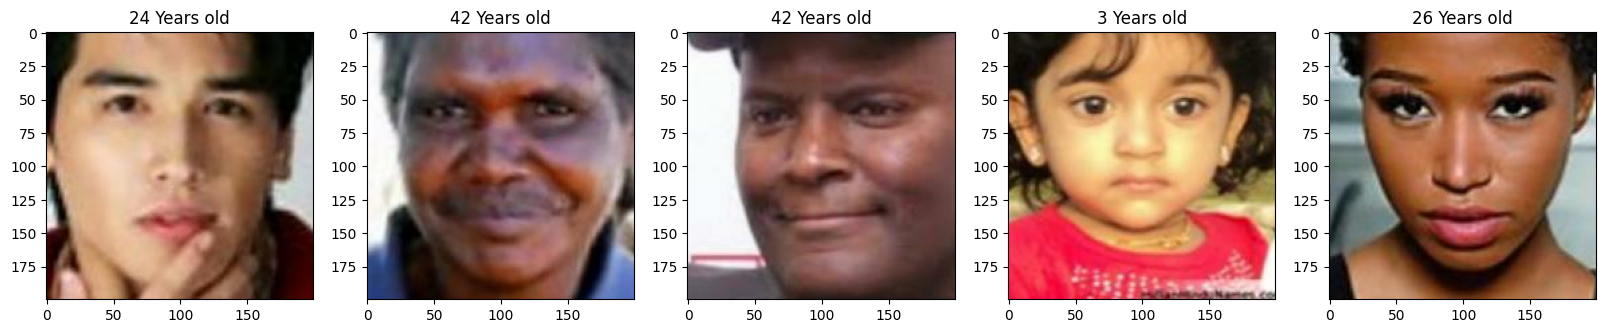

In [9]:
np.random.seed(10)
plot_imgs(filenames, ages)

Let us assume a model, such that, looking at a given person's face, it attributes the age uncertainty as following a truncated Normal distribution. Indeed, it seems reasonable that given the model's age guess, its confidence about the age be symmetrical, with symmetrical errors. Note that does not mean we are assuming the age distribution in a population to be normally distributed, but that given an image, the estimate we give for a person's age may be modeled as a truncated $N(\mu, \sigma^2) \mathbb{I}_{>0}$.

In [10]:
import multiprocessing

# Dynamically get the number of CPU cores to act as a "safe" autotune
cpu_cores = multiprocessing.cpu_count()

# Full size samples
n_train_samples = 15173
n_val_samples = 3793
n_test_samples = 4742

# Initial samples for testing model architecture
# n_train_samples = 2500
# n_val_samples = 628
# n_test_samples = 628

# Create the base pipeline first
base_ds = tf.data.Dataset.from_tensor_slices((filenames_train, ages_train))
# base_ds = base_ds.map(process_path, num_parallel_calls = tf.data.AUTOTUNE)
# base_ds = base_ds.map(process_path, num_parallel_calls = cpu_cores)
base_ds = base_ds.map(process_path)

# Extract train and validation separately
train_ds = base_ds.take(n_train_samples)
val_ds = base_ds.skip(n_train_samples).take(n_val_samples)

train_batch_size = 16
unshuffled_train_ds = train_ds
unshuffled_train_ds = unshuffled_train_ds.cache()
unshuffled_train_ds = unshuffled_train_ds.batch(train_batch_size)
unshuffled_train_ds = unshuffled_train_ds.prefetch(tf.data.AUTOTUNE)

# Train Pipeline: Cache -> SHUFFLE -> BATCH -> Prefetch
train_batch_size = 16
train_ds = train_ds.cache()
train_ds = train_ds.shuffle(buffer_size = 2000, reshuffle_each_iteration = True, seed = 10)
train_ds = train_ds.batch(train_batch_size)
train_ds = train_ds.prefetch(tf.data.AUTOTUNE)

n_train_batches = n_train_samples / train_batch_size
if( not n_train_batches.is_integer() ):
    n_train_batches = int(n_train_batches) + 1
else:
    n_train_batches = int(n_train_batches)

val_batch_size = 16
# Validation Pipeline: Cache -> BATCH -> Prefetch (Never shuffle validation)
val_ds = val_ds.cache()
val_ds = val_ds.batch(val_batch_size)
val_ds = val_ds.prefetch(tf.data.AUTOTUNE)

n_val_batches = n_val_samples / val_batch_size
if( not n_val_batches.is_integer() ):
    n_val_batches = int(n_val_batches) + 1
else:
    n_val_batches = int(n_val_batches)

# Test Pipeline: Cache -> BATCH -> Prefetch
base_test_ds = tf.data.Dataset.from_tensor_slices((filenames_test, ages_test))
# base_test_ds = base_test_ds.map(process_path, num_parallel_calls = tf.data.AUTOTUNE)
# base_test_ds = base_test_ds.map(process_path, num_parallel_calls = cpu_cores)
base_test_ds = base_test_ds.map(process_path)
test_ds = base_test_ds.take(n_test_samples)

test_batch_size = 16
test_ds = test_ds.cache()
test_ds = test_ds.batch(test_batch_size)
test_ds = test_ds.prefetch(tf.data.AUTOTUNE)

n_test_batches = n_test_samples / test_batch_size
if( not n_test_batches.is_integer() ):
    n_test_batches = int(n_test_batches) + 1
else:
    n_test_batches = int(n_test_batches)

print("Number of train batches: {}".format(n_train_batches))
print("Number of val batches: {}".format(n_val_batches))
print("Number of test batches: {}".format(n_test_batches))

Number of train batches: 949
Number of val batches: 238
Number of test batches: 297


In [11]:
train_iterator = iter(unshuffled_train_ds)

--- Unbatched Single Observation ---
Image shape: (200, 200, 3), dtype: <dtype: 'float32'>
Age value: [73.], dtype: <dtype: 'float32'>
Image Min pixel: -1.0
Image Max pixel: 1.0


Text(0.5, 1.0, 'tf.Tensor([73.], shape=(1,), dtype=float32)')

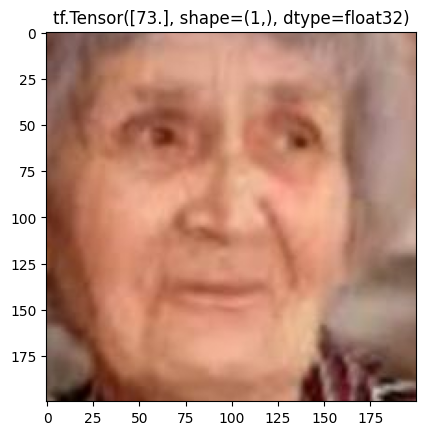

In [12]:
# Create an iterator and get the first element

sample_tuple = next(train_iterator)

# Unpack it based on your process_path function
sample_x, sample_age = sample_tuple[0][0], sample_tuple[1][0]

print("--- Unbatched Single Observation ---")
print(f"Image shape: {sample_x.shape}, dtype: {sample_x.dtype}")
print(f"Age value: {sample_age}, dtype: {sample_age.dtype}")

# Optional: Verify the MobileNetV2 scaling (-1 to 1)
print(f"Image Min pixel: {tf.reduce_min(sample_x)}")
print(f"Image Max pixel: {tf.reduce_max(sample_x)}")

plt.imshow( ((sample_x + 1.0) * 127.5).numpy().astype("int") )
plt.title( sample_age )

Here, we will me assuming that, given the image, $X$, of a face, then the age, $Y$, of that person will follow a $\text{Gamma}(k, \theta(X))$ distribution, where both parameters are constrained by an exponential inverse link function. With that, we enforce that all the predicted ages will be positive valued.

In [13]:
def build_utkface_model( dropout_rate = 0.3 ):
    tn_parameters = {
        "mu": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn",
               "shape": 1, "init": np.median(ages_train), "warmup_time": 0},
        "sigma": {"link": tf.math.exp, "link_inv": tf.math.log, "par_type": "nn", "shape": 1,
                  "init": np.std(ages_train, ddof = 1), "warmup_time": 0}
    }

    def tn_loglikelihood_loss(model, nn_output, data):
        X, y = data
        
        # Extract variables from the neural network output
        mu = model.get_variable("mu", nn_output)
        sigma = model.get_variable("sigma", nn_output)

        # Flatten to ensure perfect dimension alignment
        y = tf.reshape(y, [-1])
        mu = tf.reshape(mu, [-1])
        sigma = tf.reshape(sigma, [-1])
        
        # Route directly into the custom analytical gradient function.
        # TensorFlow will use @tf.custom_gradient definitions under the hood
        # rather than trying to AutoDiff through the truncation boundaries.
        loglik_tensor = truncnorm.log_pdf(y, mu, sigma)
        
        # Return the Negative Log-Likelihood (NLL)
        return -tf.reduce_sum( loglik_tensor )

    def tn_neural_network(model, seed = None):
        initializer = initializers.GlorotNormal(seed = seed)
        
        model.feature_extractor = tf.keras.applications.MobileNetV2(
            input_shape = (200, 200, 3),
            include_top = False,
            weights = 'imagenet',
            pooling = 'avg'
        )

        # We train the MobileNetV2 weights only from the 100th layer forward.
        # By fine-tuning that model, we are able to obtain more granular and specific traits
        # particularly related to our problem and corresponding loss function
        model.feature_extractor.trainable = True
        for layer in model.feature_extractor.layers[:100]:
            layer.trainable = False

        model.dropout = keras.layers.Dropout(dropout_rate)

        model.dense1 = keras.layers.Dense(
            units = 128, 
            activation = tf.nn.gelu, 
            kernel_initializer = initializer,
            dtype = tf.float32,
            name = "flattened_layer"
        )
        
        model.dense2 = keras.layers.Dense(
            units = 64, 
            activation = tf.nn.gelu, 
            kernel_initializer = initializer,
            dtype = tf.float32,
            name = "LLLA_layer"
        )

        model.dense3 = keras.layers.Dense(
            units = 2, 
            activation = None, 
            use_bias = True,
            bias_initializer = initializer,
            dtype = tf.float32,
            name = "normal_output"
        )
    
    def tn_neural_network_call(model, x_input, training = False):
        features = model.feature_extractor(x_input, training = training)
        x = model.dropout(features, training = training)
        x = model.dense1(x)
        x = model.dense2(x)
        output = model.dense3(x)
        return output
    
    def tn_neural_network_call_nolast(model, x_input):
        features = model.feature_extractor(x_input, training = False) 
        x = model.dropout(features, training = False)
        x = model.dense1(x)
        x = model.dense2(x)
        return x

    return tn_parameters, tn_loglikelihood_loss, tn_neural_network, tn_neural_network_call, tn_neural_network_call_nolast

We have a total of 60 training batches of size 256. We will perform training considering the Mini-Batch Gradient Descent, updating the weights on every batch the model is able to look. That speeds up training a lot and lead to better local loss minima in general. By smoothing all samples into a sample gradient and only then applying (Full-batch gradient descent, we end up with a very smooth loss curve that decreases painfully slow and may stabilize into local minima often). Therefore, we must consider here that gradient_accumulation_steps = 1.

In [14]:
with tf.device("/GPU:0"):
    tn_parameters, tn_loglikelihood_loss, tn_neural_network, tn_neural_network_call, tn_neural_network_call_nolast = \
    build_utkface_model( dropout_rate = 0.3 )
    seed = 10
    utkfaces_model = thf.ModelNN(tn_parameters, tn_loglikelihood_loss,
                                 tn_neural_network, tn_neural_network_call,
                                 tn_neural_network_call_nolast, input_dim = (200,200,3), seed = seed)
    utkfaces_model.load_model("whole_sample_training_mobilenet_layers")

/tmp/ipykernel_52553/4028780930.py:32: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  model.feature_extractor = tf.keras.applications.MobileNetV2(


Model successfully loaded from whole_sample_training_mobilenet_layers.


In [15]:
model_predict_test = utkfaces_model.predict(test_ds)
mu_test = model_predict_test["mu"].numpy().flatten()
sigma_test = model_predict_test["sigma"].numpy().flatten()

I0000 00:00:1791230172.401377   52767 cuda_dnn.cc:529] Loaded cuDNN version 92600
Could not load symbol cuStreamGetGreenCtx. Error: /lib/x86_64-linux-gnu/libcuda.so.1: undefined symbol: cuStreamGetGreenCtx


In [16]:
def log_tn_lower_quantile(model, nn_output, data):
    mu = model.get_variable("mu", nn_output)
    sigma = model.get_variable("sigma", nn_output)
    
    # Standard Normal baseline
    norm_dist = tfp.distributions.Normal(loc = 0.0, scale = 1.0)
    
    # Compute alpha = Phi(-mu/sigma)
    alpha = norm_dist.cdf(-mu / sigma)
    
    # Adjust the 2.5% target for the [0, inf] truncation
    p_target = 0.025
    adjusted_p = alpha + p_target * (1.0 - alpha)
    
    # Clip the probability slightly inside [0, 1] 
    # Prevents GradientTape from hitting the ndtri singularities
    adjusted_p_safe = tf.clip_by_value(adjusted_p, 1e-7, 1.0 - 1e-7)
    
    # Map back through the inverse CDF and scale
    q_025 = mu + sigma * norm_dist.quantile(adjusted_p_safe)
    
    # Return the log to match theoretical framework
    return tf.math.log(q_025)

def log_tn_upper_quantile(model, nn_output, data):
    mu = model.get_variable("mu", nn_output)
    sigma = model.get_variable("sigma", nn_output)
    
    norm_dist = tfp.distributions.Normal(loc = 0.0, scale = 1.0)
    
    alpha = norm_dist.cdf(-mu / sigma)
    
    p_target = 0.975
    adjusted_p = alpha + p_target * (1.0 - alpha)
    
    adjusted_p_safe = tf.clip_by_value(adjusted_p, 1e-7, 1.0 - 1e-7)
    q_975 = mu + sigma * norm_dist.quantile(adjusted_p_safe)
    
    return tf.math.log(q_975)

In [17]:
test_imgs = np.concatenate([img for img, age in test_ds.as_numpy_iterator()], axis = 0)
test_ages = np.concatenate([age for img, age in test_ds.as_numpy_iterator()], axis = 0).flatten()

tnorm_dist_test = tfp.distributions.TruncatedNormal(loc = mu_test, scale = sigma_test, low = 0.0, high = np.inf)
log_tn_lower_quantile_hat_test = np.log( tnorm_dist_test.quantile( 0.025 ) )
log_tn_upper_quantile_hat_test = np.log( tnorm_dist_test.quantile( 0.975 ) )

alpha = 0.05
z_norm = norm.ppf(1-alpha/2)

log_tn_lower_quantile_covariances_test = utkfaces_model.variable_function_covariance(
    fun = log_tn_lower_quantile,
    data = [],
    x = test_ds
).numpy().flatten()

log_tn_upper_quantile_covariances_test = utkfaces_model.variable_function_covariance(
    fun = log_tn_upper_quantile,
    data = [], 
    x = test_ds
).numpy().flatten()

lower_log_tn_lower_quantile_test = log_tn_lower_quantile_hat_test - np.sqrt(log_tn_lower_quantile_covariances_test) * z_norm
upper_log_tn_upper_quantile_test = log_tn_upper_quantile_hat_test + np.sqrt(log_tn_upper_quantile_covariances_test) * z_norm
lower_tn_lower_quantile_test = np.exp( lower_log_tn_lower_quantile_test )
upper_tn_upper_quantile_test = np.exp( upper_log_tn_upper_quantile_test )

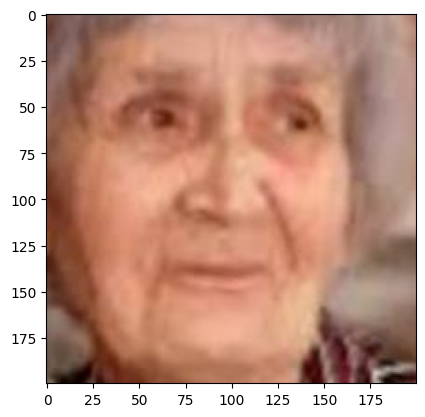

In [18]:
img = sample_tuple[0][0]
plt.imshow( ((img + 1.0) * 127.5).numpy().astype("int") )
plt.show()

In [19]:
utkfaces_model.predict(tf.expand_dims(img, axis = 0))

{'mu': <tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[70.76693]], dtype=float32)>,
 'sigma': <tf.Tensor: shape=(1, 1), dtype=float32, numpy=array([[5.60015]], dtype=float32)>}

In [20]:
exp_img = tf.expand_dims(img, axis = 0)
utkfaces_model.summary(exp_img)

,index,mu,mu_se,mu_lower,mu_upper,sigma,sigma_se,sigma_lower,sigma_upper
0,1,70.76693,0.554929,69.687599,71.862976,5.60015,0.283656,5.070899,6.184638


In [21]:
img_lower_quantile = utkfaces_model.variable_function_covariance(
    fun = log_tn_lower_quantile,
    data = [],
    x = exp_img
).numpy().flatten()

img_upper_quantile = utkfaces_model.variable_function_covariance(
    fun = log_tn_upper_quantile,
    data = [], 
    x = exp_img
).numpy().flatten()

img_pred = utkfaces_model.predict(tf.expand_dims(img, axis = 0))

mu_pred = img_pred["mu"]
sigma_pred = img_pred["sigma"]

tnorm_dist_test = tfp.distributions.TruncatedNormal(loc = mu_pred, scale = sigma_pred, low = 0.0, high = np.inf)
img_lower_quantile_hat = np.log( tnorm_dist_test.quantile( 0.025 ) )
img_upper_quantile_hat = np.log( tnorm_dist_test.quantile( 0.975 ) )

img_lower_log_tn_lower_quantile = img_lower_quantile_hat - np.sqrt(img_lower_quantile) * z_norm
img_upper_log_tn_upper_quantile = img_upper_quantile_hat + np.sqrt(img_upper_quantile) * z_norm
img_lower_tn_lower_quantile = np.exp( img_lower_log_tn_lower_quantile )
img_upper_tn_upper_quantile = np.exp( img_upper_log_tn_upper_quantile )

In [100]:
def log_tn_lower_quantile(model, nn_output, data):
    mu = model.get_variable("mu", nn_output)
    sigma = model.get_variable("sigma", nn_output)
    
    # Standard Normal baseline
    norm_dist = tfp.distributions.Normal(loc = 0.0, scale = 1.0)
    
    # Compute alpha = Phi(-mu/sigma)
    alpha = norm_dist.cdf(-mu / sigma)
    
    # Adjust the 2.5% target for the [0, inf] truncation
    p_target = 0.025
    adjusted_p = alpha + p_target * (1.0 - alpha)
    
    # Clip the probability slightly inside [0, 1] 
    # Prevents GradientTape from hitting the ndtri singularities
    adjusted_p_safe = tf.clip_by_value(adjusted_p, 1e-7, 1.0 - 1e-7)
    
    # Map back through the inverse CDF and scale
    q_025 = mu + sigma * norm_dist.quantile(adjusted_p_safe)
    
    # Return the log to match theoretical framework
    return tf.math.log(q_025)

def log_tn_upper_quantile(model, nn_output, data):
    mu = model.get_variable("mu", nn_output)
    sigma = model.get_variable("sigma", nn_output)
    
    norm_dist = tfp.distributions.Normal(loc = 0.0, scale = 1.0)
    
    alpha = norm_dist.cdf(-mu / sigma)
    
    p_target = 0.975
    adjusted_p = alpha + p_target * (1.0 - alpha)
    
    adjusted_p_safe = tf.clip_by_value(adjusted_p, 1e-7, 1.0 - 1e-7)
    q_975 = mu + sigma * norm_dist.quantile(adjusted_p_safe)
    
    return tf.math.log(q_975)

def predict_age(img):
    exp_img = tf.expand_dims(img, axis = 0)
    utkfaces_model.predict(exp_img)

    img_lower_quantile = utkfaces_model.variable_function_covariance(
        fun = log_tn_lower_quantile,
        data = [],
        x = exp_img
    ).numpy().flatten()
    
    img_upper_quantile = utkfaces_model.variable_function_covariance(
        fun = log_tn_upper_quantile,
        data = [], 
        x = exp_img
    ).numpy().flatten()
    
    img_pred = utkfaces_model.predict(tf.expand_dims(img, axis = 0))
    
    mu_pred = img_pred["mu"].numpy()[0,0]
    sigma_pred = img_pred["sigma"].numpy()[0,0]
    
    tnorm_dist_test = tfp.distributions.TruncatedNormal(loc = mu_pred, scale = sigma_pred, low = 0.0, high = np.inf)
    img_lower_quantile_hat = np.log( tnorm_dist_test.quantile( 0.025 ) )
    img_upper_quantile_hat = np.log( tnorm_dist_test.quantile( 0.975 ) )
    
    img_lower_log_tn_lower_quantile = img_lower_quantile_hat - np.sqrt(img_lower_quantile) * z_norm
    img_upper_log_tn_upper_quantile = img_upper_quantile_hat + np.sqrt(img_upper_quantile) * z_norm
    img_lower_tn_lower_quantile = np.exp( img_lower_log_tn_lower_quantile )
    img_upper_tn_upper_quantile = np.exp( img_upper_log_tn_upper_quantile )

    return mu_pred, sigma_pred, img_lower_tn_lower_quantile, img_upper_tn_upper_quantile

In [155]:
def plot_age_distribution(x, age, mu, sigma, lower_age, upper_age, ax1 = None, ax2 = None):
    if(ax1 is None or ax2 is None):
        fig, ax = plt.subplots(nrows = 1, ncols = 2, figsize = (12,6))
        ax1 = ax[0]
        ax2 = ax[1]

    ax1.imshow( ((x + 1.0) * 127.5).astype("int") )
    ax1.set_axis_off()  

    ts = np.linspace(0.001, 100, 500)

    a_std = (0.0 - mu) / sigma
    norm_ts = truncnorm_scipy.pdf(ts, loc = mu, scale = sigma, a = a_std, b = np.inf)

    ax2.plot(ts, norm_ts, label = "Age distribution", color = "blue")
    ax2.axvline(age, label = "True age", color = "red")
    
    ax2.axvline(lower_age, color = "blue", linestyle = "dashed", label = "Predictive interval")
    ax2.axvline(upper_age, color = "blue", linestyle = "dashed")
    # ax2.legend(loc = "upper left")

    ax2.tick_params(axis = "both", which = "major", labelsize = 16)

In [78]:
def plot_age_distribution2(x, age, mu, sigma, lower_age, upper_age, ax1 = None, ax2 = None, ax3 = None):
    if(ax1 is None or ax2 is None):
        fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (20,12),
                       gridspec_kw = {
                           'width_ratios': [6, 1, 6],
                           'height_ratios': [1, 1, 1]
                       })
        ax1 = ax[0]
        ax2 = ax[1]
        ax3 = ax[2]

    ax1.imshow( ((x + 1.0) * 127.5).astype("int") )
    ax1.set_axis_off()

    right_arrow_img = np.array( Image.open("assets/right_arrow.png").convert("RGBA") )
    ax2.imshow(right_arrow_img)
    ax2.set_axis_off()

    ts = np.linspace(0.001, 100, 500)

    a_std = (0.0 - mu) / sigma
    norm_ts = truncnorm_scipy.pdf(ts, loc = mu, scale = sigma, a = a_std, b = np.inf)

    ax3.plot(ts, norm_ts, label = "Age distribution", color = "blue")
    ax3.axvline(age, label = "True age", color = "red")
    
    ax3.axvline(lower_age, color = "blue", linestyle = "dashed", label = "Predictive interval")
    ax3.axvline(upper_age, color = "blue", linestyle = "dashed")

    # ax2.legend(loc = "upper left")

In [142]:
from mtcnn import MTCNN

detector = MTCNN()

def load_img(filename):
    img = tf.io.read_file(filename)
    img_tf = tf.image.decode_jpeg(img, channels = 3)
    img_np = img_tf.numpy()
    
    resultados = detector.detect_faces(img_np)
    
    if len(resultados) == 0:
        raise Exception("Nenhum rosto detectado!")
    
    rosto_principal = max(resultados, key=lambda b: b['confidence'])
    x, y, width, height = rosto_principal['box']
    
    # Previne valores negativos do MTCNN
    x, y = max(0, x), max(0, y)
    
    # Encontra o centro exato do rosto
    centro_x = x + width // 2
    centro_y = y + height // 2
    
    # Transforma em quadrado pegando a maior dimensão
    lado_maximo = max(width, height)
    
    # Multiplica por 1.6 para dar margem (afastar o zoom)
    fator_margem = 1.6
    tamanho_quadrado = int(lado_maximo * fator_margem)
    
    # Calcula as novas coordenadas X, Y do topo superior esquerdo
    novo_x = centro_x - (tamanho_quadrado // 2)
    novo_y = centro_y - (tamanho_quadrado // 2)
    
    # 5. Garante que o recorte não vai pedir pixels fora da foto (padding natural)
    img_height, img_width, _ = img_np.shape
    x1 = max(0, novo_x)
    y1 = max(0, novo_y)
    x2 = min(img_width, novo_x + tamanho_quadrado)
    y2 = min(img_height, novo_y + tamanho_quadrado)
    
    largura_corte = x2 - x1
    altura_corte = y2 - y1
    
    # Recorta usando TensorFlow
    pic_crop = tf.image.crop_to_bounding_box(
        img_tf, 
        offset_height=y1, 
        offset_width=x1, 
        target_height=altura_corte, 
        target_width=largura_corte
    )
    
    pic_resize = tf.image.resize(pic_crop, [200, 200])
    
    pic_normalized = tf.cast(pic_resize, tf.float32)
    pic_normalized = pic_normalized / np.max(pic_normalized) * 2.0 - 1.0
    
    return pic_normalized.numpy()

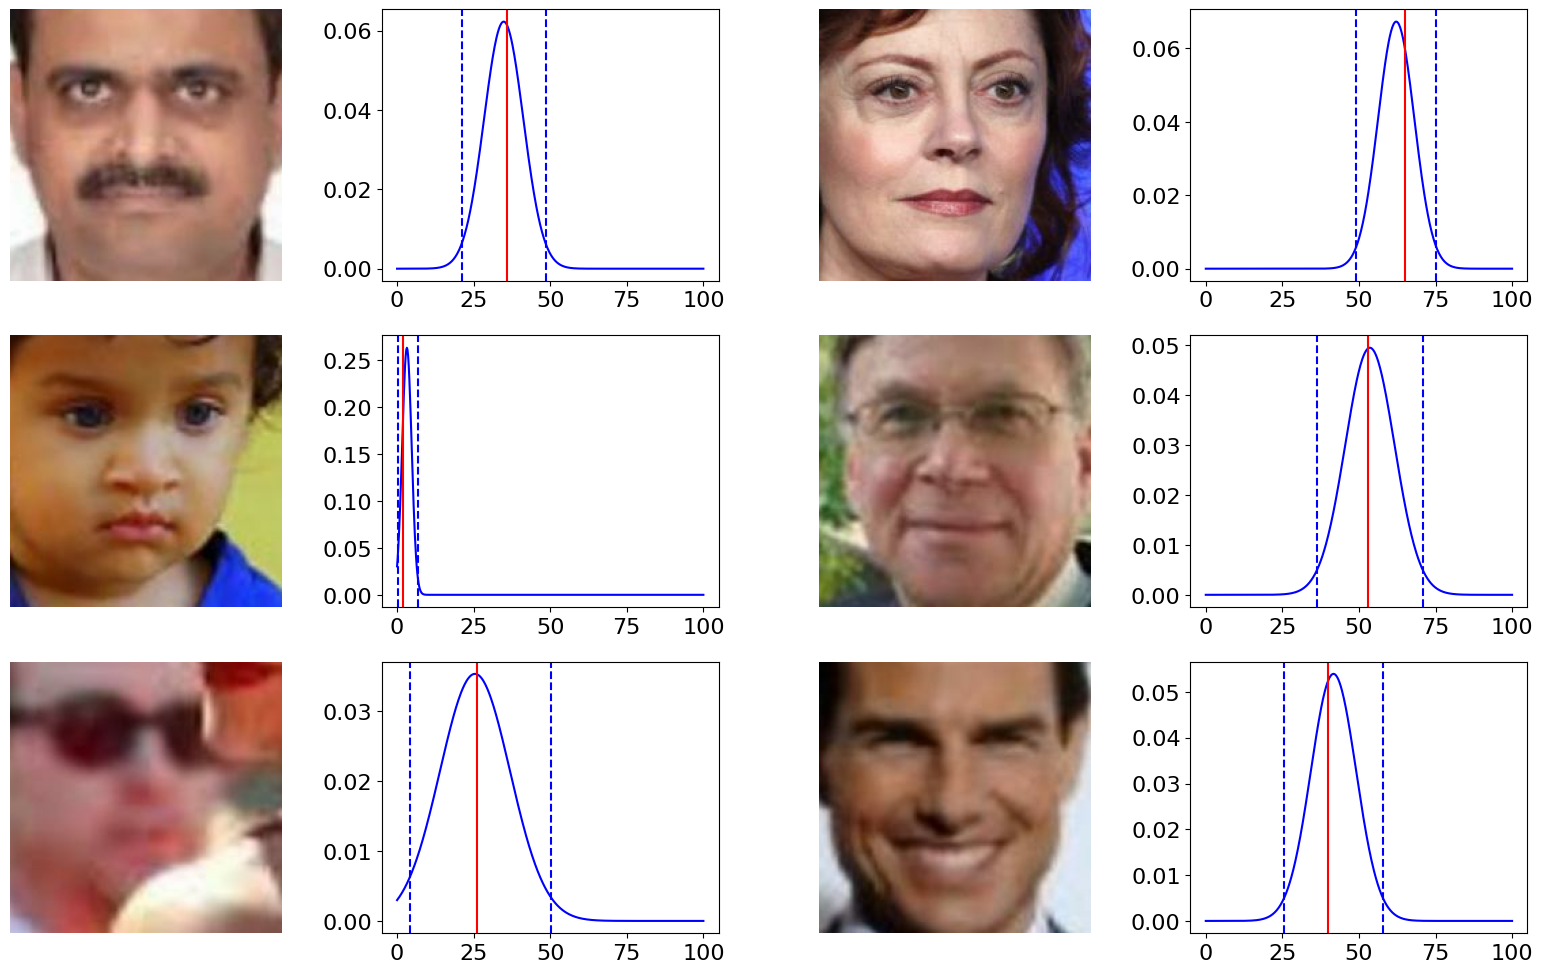

In [156]:
# np.random.seed(120)
# idx = np.random.choice(np.arange(0, test_imgs.shape[0]), size = 6, replace = False)

idx = [0, 4, 10, 18, 29, 103]

fig, ax = plt.subplots(nrows = 3, ncols = 4, figsize = (20,12))

plot_age_distribution(test_imgs[idx[0]], test_ages[idx[0]], mu_test[idx[0]], sigma_test[idx[0]], lower_tn_lower_quantile_test[idx[0]], upper_tn_upper_quantile_test[idx[0]], ax1 = ax[0,0], ax2 = ax[0,1])
plot_age_distribution(test_imgs[idx[1]], test_ages[idx[1]], mu_test[idx[1]], sigma_test[idx[1]], lower_tn_lower_quantile_test[idx[1]], upper_tn_upper_quantile_test[idx[1]], ax1 = ax[1,0], ax2 = ax[1,1])
plot_age_distribution(test_imgs[idx[2]], test_ages[idx[2]], mu_test[idx[2]], sigma_test[idx[2]], lower_tn_lower_quantile_test[idx[2]], upper_tn_upper_quantile_test[idx[2]], ax1 = ax[2,0], ax2 = ax[2,1])
plot_age_distribution(test_imgs[idx[3]], test_ages[idx[3]], mu_test[idx[3]], sigma_test[idx[3]], lower_tn_lower_quantile_test[idx[3]], upper_tn_upper_quantile_test[idx[3]], ax1 = ax[0,2], ax2 = ax[0,3])
plot_age_distribution(test_imgs[idx[4]], test_ages[idx[4]], mu_test[idx[4]], sigma_test[idx[4]], lower_tn_lower_quantile_test[idx[4]], upper_tn_upper_quantile_test[idx[4]], ax1 = ax[1,2], ax2 = ax[1,3])
plot_age_distribution(test_imgs[idx[5]], test_ages[idx[5]], mu_test[idx[5]], sigma_test[idx[5]], lower_tn_lower_quantile_test[idx[5]], upper_tn_upper_quantile_test[idx[5]], ax1 = ax[2,2], ax2 = ax[2,3])

(np.float64(-0.5), np.float64(199.5), np.float64(199.5), np.float64(-0.5))

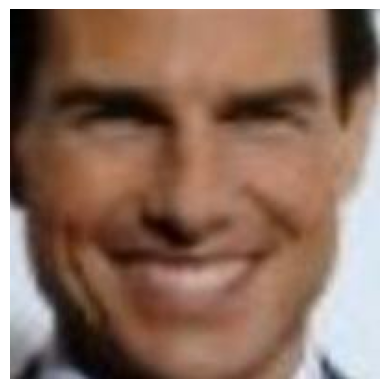

In [164]:
plt.imshow( ((test_imgs[idx[5]] + 1.0) * 127.5).astype("int") )
plt.axis('off')

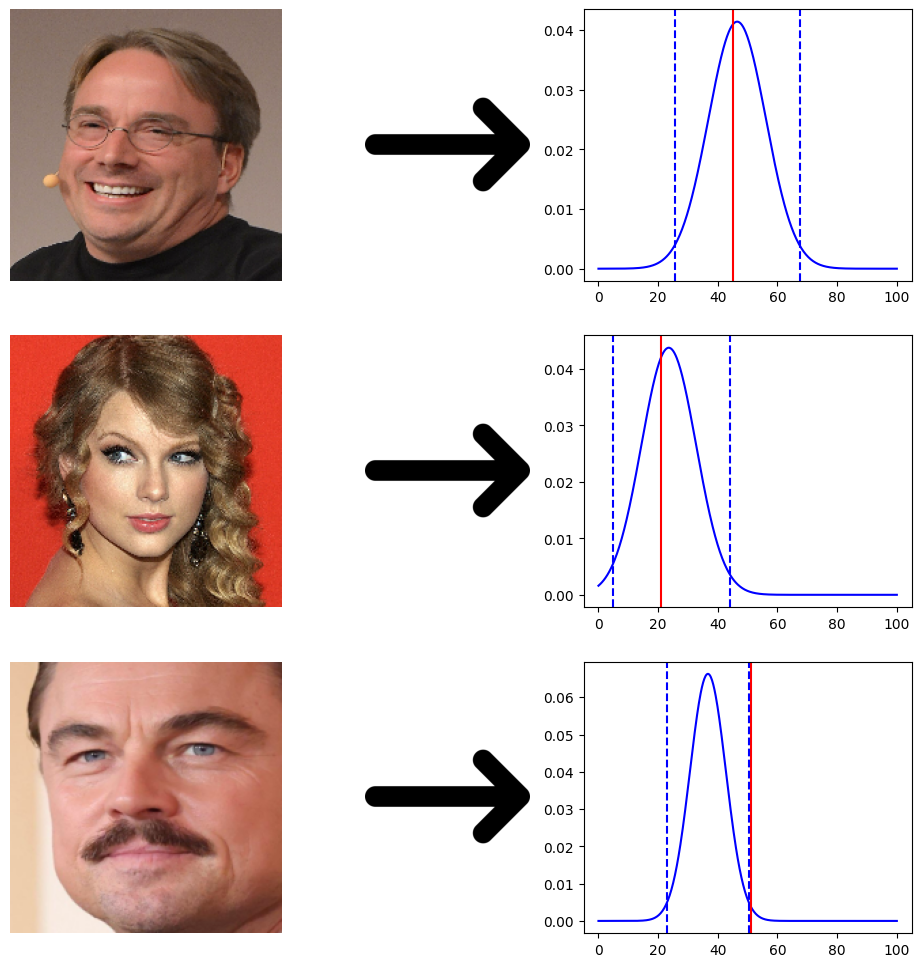

In [151]:
# np.random.seed(120)
idx = np.random.choice(np.arange(0, test_imgs.shape[0]), size = 6, replace = False)

idx = [0, 4, 10, 18, 29, 103]

linus45 = load_img("Celebrity/linus45.jpg")
linus45_mu_pred, linus45_sigma_pred, linus45_age_lower, linus45_age_upper = predict_age(linus45)

taylor30 = load_img("Celebrity/taylor21.jpg")
taylor30_mu_pred, taylor30_sigma_pred, taylor30_age_lower, taylor30_age_upper = predict_age(taylor30)

leo51 = load_img("Celebrity/Leonardo DiCaprio/51.png")
leo51_mu_pred, leo51_sigma_pred, leo51_age_lower, leo51_age_upper = predict_age(leo51)

fig, ax = plt.subplots(nrows = 3, ncols = 3, figsize = (12,12),
                       gridspec_kw = {
                           'width_ratios': [1, 0.5, 1],
                           'height_ratios': [1, 1, 1]
                       })

plot_age_distribution2(linus45, 45, linus45_mu_pred, linus45_sigma_pred, linus45_age_lower, linus45_age_upper, ax1 = ax[0,0], ax2 = ax[0,1], ax3 = ax[0,2])
plot_age_distribution2(taylor30, 21, taylor30_mu_pred, taylor30_sigma_pred, taylor30_age_lower, taylor30_age_upper, ax1 = ax[1,0], ax2 = ax[1,1], ax3 = ax[1,2])
plot_age_distribution2(leo51, 51, leo51_mu_pred, leo51_sigma_pred, leo51_age_lower, leo51_age_upper, ax1 = ax[2,0], ax2 = ax[2,1], ax3 = ax[2,2])